# **Dimensionality Reduction** (Sesi 21-22, 18 May 2026)

Fadhlan Nur Rachman (2802491960)

In [1]:
# import dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df =pd.read_csv('winedataset/WineQT.csv')
print(df.shape)
df.head()

(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


**Interpretasi cell diatas**:

terdapat data kualitas wine/alkohol yang akan diolah dan memiliki informasi sebanyak 1143 baris dan 12 fitur serta 1 label (quality).


In [2]:
# Drop Unnecessery Column

df = df.drop('Id', axis=1)
print(df.shape)
df.head()

(1143, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**Interpretasi cell diatas**:

kolom Id dihapus karena hanya berfungsi sebagai nomor urut tanpa nilai analitis apapun dan pasti memiliki unique value tinggi

# Exploratory Data Analysis

In [3]:
# Check Structured Data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


**Interpretasi cell diatas**:

seluruh 12 kolom terisi penuh tanpa missing value dengan total 1143 baris. semua fitur bertipe float64 kecuali quality yang bertipe int64. tipe data sudah sesuai dan tidak perlu konversi apapun

In [4]:
# Calculate Summary Statistics

df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


**Interpretasi cell diatas**:

ringkasan statistik menampilkan persebaran setiap fitur. beberapa fitur seperti chlorides dan total sulfur dioxide memiliki nilai max yang sangat jauh dari Q3 yang mengindikasikan adanya outlier. rata-rata quality adalah 5.66 dengan rentang nilai dari 3 sampai 8

In [5]:
# Check Missing Values

df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

**Interpretasi cell diatas**:

tidak ada missing value di semua fitur, setiap kolom terisi lengkap 1143 baris. data bersih dari sisi null value sehingga tidak perlu imputasi

In [6]:
# Check Duplicate Values

print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 125


**Interpretasi cell diatas**:

ditemukan 125 baris data yang identik satu sama lain. duplikat ini harus dihapus agar model tidak belajar dari informasi yang sama berulang kali yang bisa menyebabkan overfitting

In [7]:
# Remove Duplicate Values

df = df.drop_duplicates()
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows after removal: 0


**Interpretasi cell diatas**:

125 baris duplikat berhasil dihapus dan dipastikan tidak ada duplikat tersisa. jumlah data berkurang dari 1143 menjadi 1018 baris yang siap diproses lebih lanjut

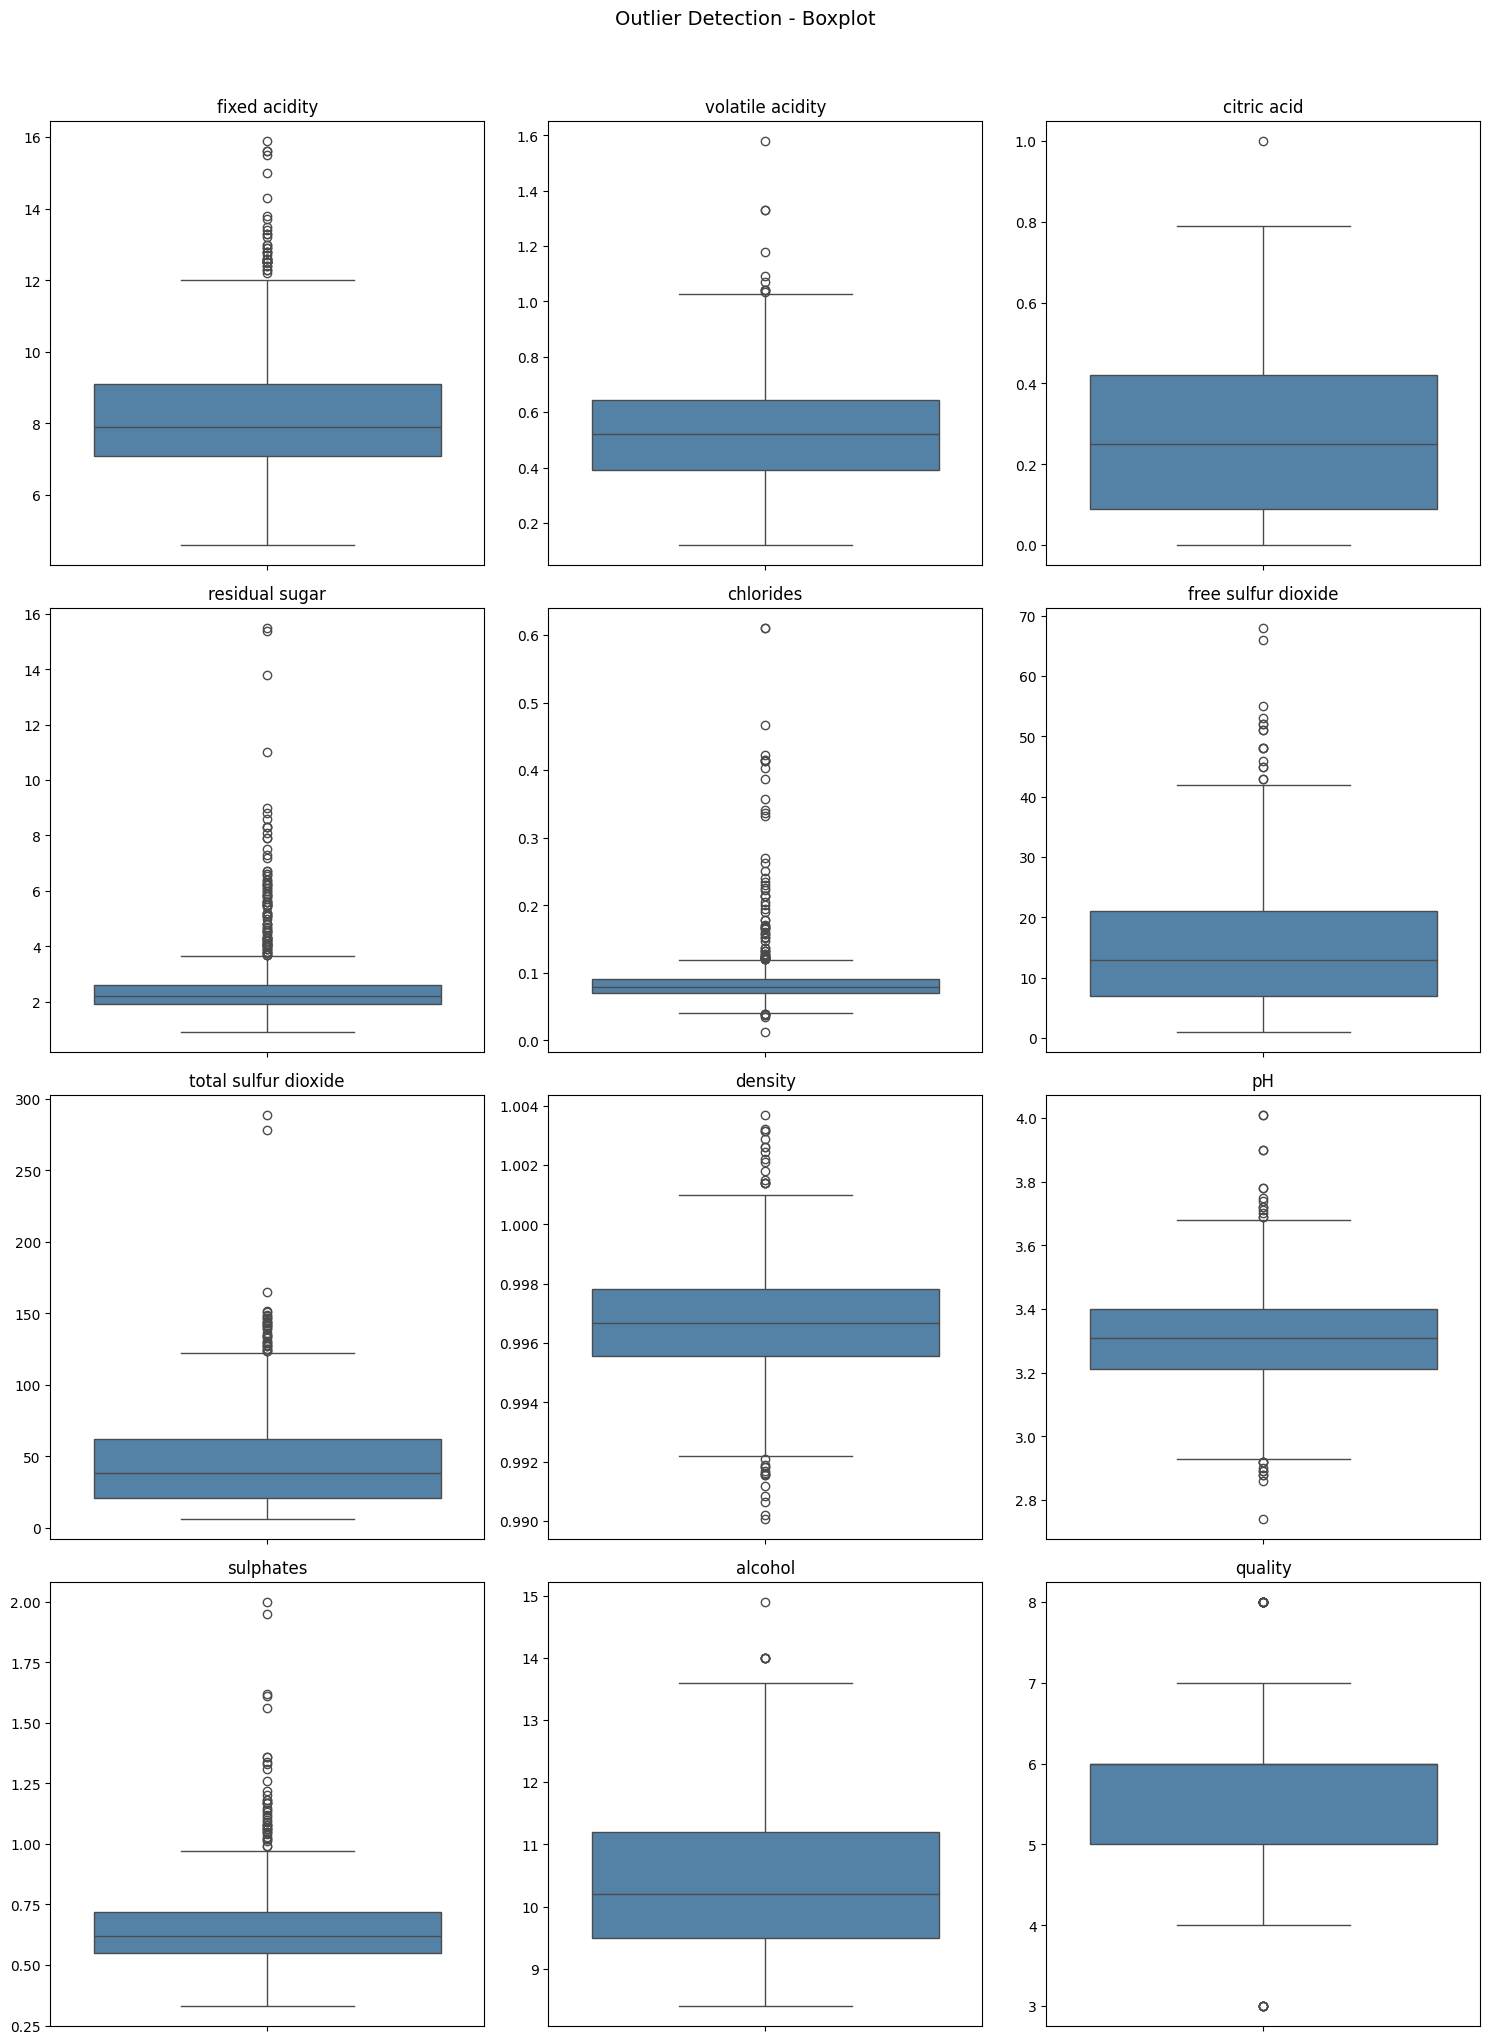

In [8]:
# Check Outlier

numeric_cols = df.select_dtypes(include='number').columns.tolist()
n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols) # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection - Boxplot', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

menampilkan boxplot yang memperlihatkan distribusi dan outlier dari setiap fitur. semua fitur punya outlier dan beberapa memiliki outlier yang cukup banyak dengan titik yang jauh di atas whisker. penggunaan RobustScaler di tahap preprocessing akan membantu meredam pengaruh outlier ini karena menggunakan median dan IQR bukan mean dan std

In [9]:
# Check for the Distribution of the Quality Variable

df['quality'].value_counts().sort_index()

quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64

**Interpretasi cell diatas**:

distribusi kualitas wine sangat tidak seimbang, kualitas 5 ada 433 data dan kualitas 6 ada 409 data mendominasi hampir 83% dataset. sementara kualitas 3 hanya ada 6 data dan kualitas 8 hanya 15 data. ini adalah masalah class imbalance yang harus diatasi sebelum modeling

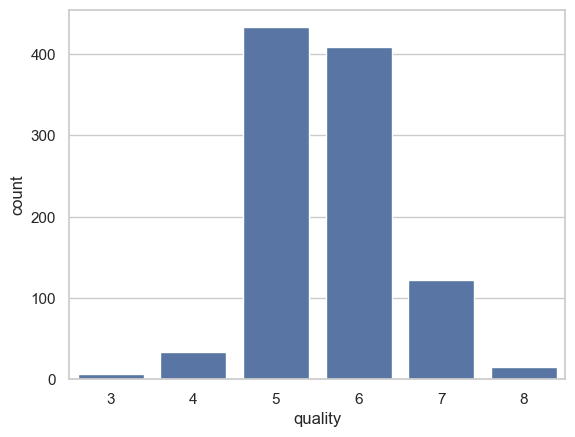

In [10]:
# Plot the distribution of the quality variable

sns.set_theme(style="whitegrid")
sns.countplot(data=df, x='quality')
plt.show()

**Interpretasi cell diatas**:

memperlihatkan bar chart dimana bar di dominasi kualitas 5 dan 6, sementara kualitas ekstrem 3 dan 8 sangat sedikit. karena class imbalance ini, binning label kualitas dibuat ulang dengan pembagian yang lebih seimbang pada tahap preprocessing

# Data Preprocessing

In [11]:
# Create Quality Categories
# skor 1-5 = Low, 6 = Medium, 7-8 = High untuk distribusi yang lebih seimbang

def categorize_quality(score):
    if score <= 5:
        return 'Low'
    elif score == 6:
        return 'Medium'
    else:
        return 'High'

In [12]:
# Apply to Target

df['quality_label'] = df['quality'].apply(categorize_quality)

print("Distribusi Quality Label")
print(df['quality_label'].value_counts())

Distribusi Quality Label
quality_label
Low       472
Medium    409
High      137
Name: count, dtype: int64


**Interpretasi cell diatas**:

kualitas wine dikelompokkan menjadi 3 kelas berdasarkan skor dan distribusi ini jauh lebih seimbang dibanding pembagian Poor/Average/Excellent sebelumnya dan membantu model belajar lebih baik di semua kelas

In [13]:
# Seperate Features and Target

df = df.drop(columns=['quality'])
X = df.drop(columns=['quality_label'])
y = df['quality_label']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")


Shape of X: (1018, 11)
Shape of y: (1018,)


**Interpretasi cell diatas**:

fitur X terdiri dari 11 kolom numerik kimiawi wine, sedangkan target y berisi label kualitas (Low, Medium, High). kolom quality numerik asli sudah dihapus karena sudah diwakili oleh quality_label, total data yang siap diproses adalah 1018 baris

In [14]:
# Split Data 80% Train adn 20% Test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("X_train shape: ", X_train.shape)
print("X_test shape: ",X_test.shape)
print("y_train shape: ",y_train.shape)
print("y_test shape: ",y_test.shape)

X_train shape:  (814, 11)
X_test shape:  (204, 11)
y_train shape:  (814,)
y_test shape:  (204,)


**Interpretasi cell diatas**:

data dibagi 80:20 menjadi 814 data training dan 204 data testing dengan parameter stratify digunakan agar proporsi kelas Low, Medium, dan High terjaga sama di kedua set, penting untuk dataset yang masih agak tidak seimbang

In [15]:
# Robust Scaling

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Interpretasi cell diatas**:

RobustScaler digunakan karena lebih tahan terhadap outlier dibanding StandardScaler. RobustScaler menggunakan median dan IQR sebagai acuan bukan mean dan standar deviasi, sehingga outlier ekstrem yang ada di fitur chlorides dan sulfur dioxide tidak terlalu mempengaruhi hasil normalisasi. fit hanya dilakukan di data train lalu diterapkan ke train dan test

# PCA (Principal Component Analysis)

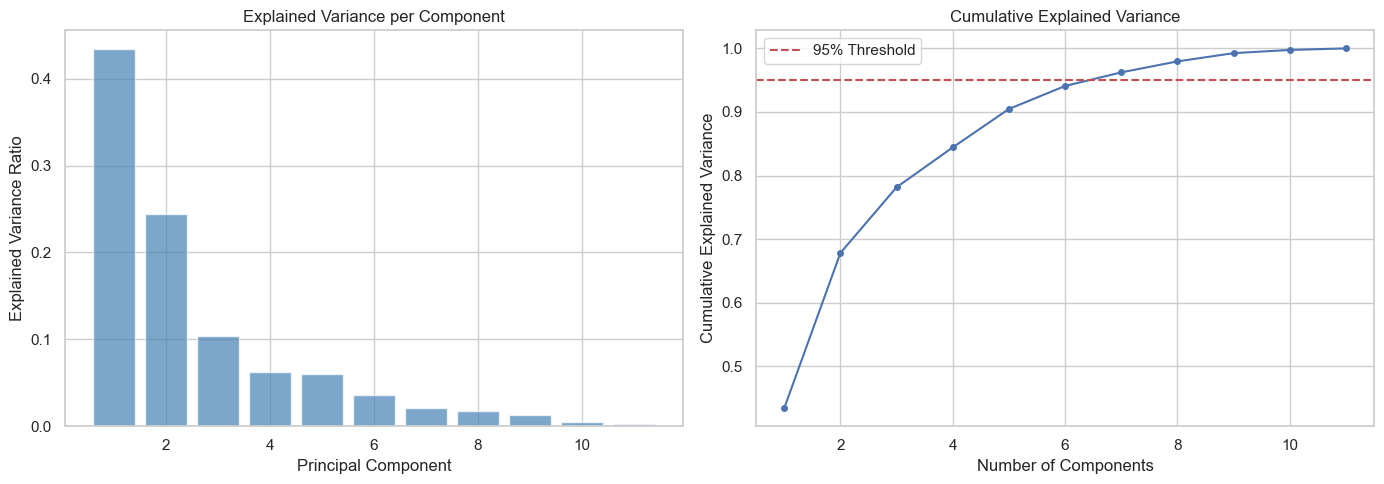

Komponen untuk 95% variance: 7


In [16]:
# Find the Optimal Number of Dimensions for PCA

from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar per Component
axes[0].bar(range(1, len(explained_variance) + 1), 
            explained_variance, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance per Component')

# Plot 2: Cumulative Variance
axes[1].plot(
    range(1, len(cumulative_variance) + 1), 
    cumulative_variance,'bo-', markersize=4
)
axes[1].axhline(y=0.95, color='r', linestyle='--', 
                label='95% Threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

# Cari n_components yang menjelaskan 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Komponen untuk 95% variance: {n_components_95}")


**Interpretasi cell diatas**:

menampilkan grafik kiri menampilkan kontribusi variansi dari masing-masing komponen PCA. grafik kanan menampilkan variansi kumulatif dengan garis merah sebagai ambang batas 95%. dari grafik ini terlihat bahwa 7 komponen sudah cukup untuk menjelaskan 95.75% informasi dari 11 fitur asli, sehingga 4 dimensi sisanya bisa dibuang

In [17]:
pca = PCA(n_components=n_components_95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Shape sebelum PCA: {X_train_scaled.shape}")
print(f"Shape setelah PCA: {X_train_pca.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Shape sebelum PCA: (814, 11)
Shape setelah PCA: (814, 7)
Variance explained: 96.23%


**Interpretasi cell diatas**:

dimensi data berhasil direduksi dari 11 menjadi 7 komponen sambil mempertahankan lebih dari 95% variansi asli. komponen yang dihapus hanya mengandung sedikit informasi yang dianggap tidak terlalu penting dan bisa mengurangi noise saat training

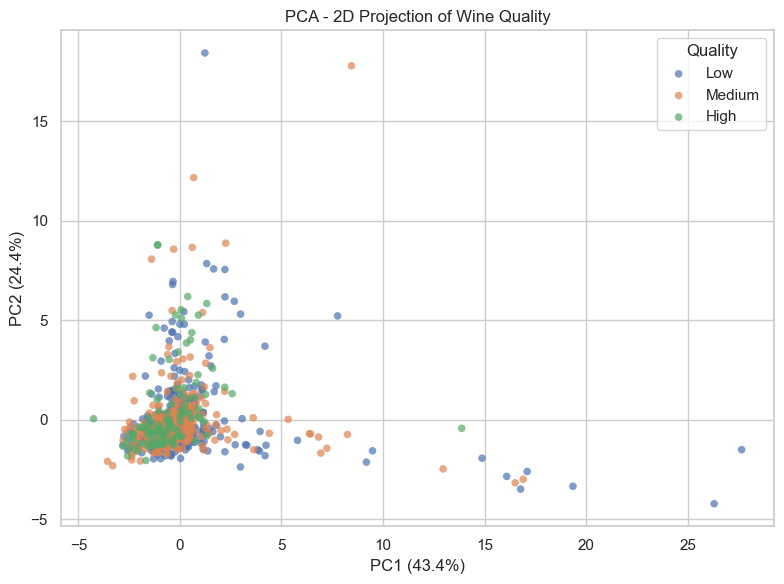

In [18]:
# Visualisasi 2D PCA

pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

label_order = ['Low', 'Medium', 'High']

fig, ax = plt.subplots(figsize=(8, 6))

for cls in label_order:
    idx = y_train == cls
    ax.scatter(
        X_train_2d[idx, 0],
        X_train_2d[idx, 1],
        label=cls,
        alpha=0.7,
        edgecolor='none',
        s=30
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA - 2D Projection of Wine Quality')
ax.legend(title='Quality')
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

proyeksi 2D PCA memperlihatkan sebaran tiga kelas wine. terlihat kelas Low, Medium, dan High masih banyak tumpang tindih karena PCA tidak mempertimbangkan label kelas saat melakukan reduksi, PCA hanya mencari arah dengan variansi terbesar. ini menjelaskan keterbatasan PCA untuk tugas klasifikasi

In [19]:
# Train Random Forest with PCA Data 

from sklearn.ensemble import RandomForestClassifier

rf_pca = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_pca.fit(X_train_pca, y_train)

# Prediksi
y_pred_pca = rf_pca.predict(X_test_pca)

**Interpretasi cell diatas**:

Random Forest dilatih menggunakan 7 komponen PCA sebagai fitur input. class_weight parameter digunakan agar model memberikan bobot lebih pada kelas minoritas (High) sehingga tidak bias ke kelas yang paling banyak datanya (Low dan Medium)

In [20]:
# Evaluasi

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

label_order = ['Low', 'Medium', 'High']

acc_pca = accuracy_score(y_test, y_pred_pca)
print(f"Accuracy with PCA: {acc_pca*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_pca, labels=label_order, zero_division=0))

Accuracy with PCA: 65.20%

Classification Report:
              precision    recall  f1-score   support

         Low       0.69      0.81      0.75        95
      Medium       0.60      0.56      0.58        82
        High       0.62      0.37      0.47        27

    accuracy                           0.65       204
   macro avg       0.64      0.58      0.60       204
weighted avg       0.65      0.65      0.64       204



**Interpretasi cell diatas**:

classification report menampilkan performa model per kelas. macro avg adalah rata-rata antar kelas tanpa mempertimbangkan jumlah data per kelas, sehingga lebih adil untuk evaluasi pada dataset yang tidak sepenuhnya seimbang. perhatikan perbedaan precision, recall, dan f1 antar kelas untuk melihat di mana model masih kesulitan

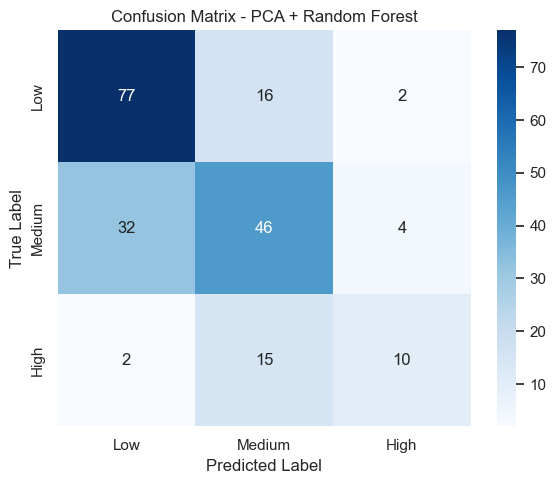

In [21]:
cm = confusion_matrix(y_test, y_pred_pca, labels=label_order)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_order,
    yticklabels=label_order,
    ax=ax
)
ax.set_title('Confusion Matrix - PCA + Random Forest')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

memperlihatkan confusion matrix detail prediksi benar dan salah per kelas. angka di diagonal utama (kiri atas ke kanan bawah) adalah prediksi yang benar, sedangkan angka di luar diagonal adalah kesalahan klasifikasi. kelas High yang datanya paling sedikit masih sering tertukar dengan kelas lain saat prediksi

# LDA (Linear Discriminant Analysis)

In [22]:
# Fit LDA dan Transformasi Data

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print(f"Shape sebelum LDA: {X_train_scaled.shape}")
print(f"Shape setelah LDA: {X_train_lda.shape}")
print(f"Variance explained: {lda.explained_variance_ratio_.sum()*100:.2f}%")

Shape sebelum LDA: (814, 11)
Shape setelah LDA: (814, 2)
Variance explained: 100.00%


**Interpretasi cell diatas**:

LDA berhasil mereduksi 11 fitur menjadi 2 komponen (LD1 dan LD2) karena dataset ini memiliki 3 kelas, sehingga maksimal komponen yang bisa dihasilkan adalah n_kelas - 1 = 2. berbeda dengan PCA yang hanya memaksimalkan variansi, LDA memaksimalkan pemisahan antar kelas sehingga lebih cocok digunakan untuk tugas klasifikasi seperti ini

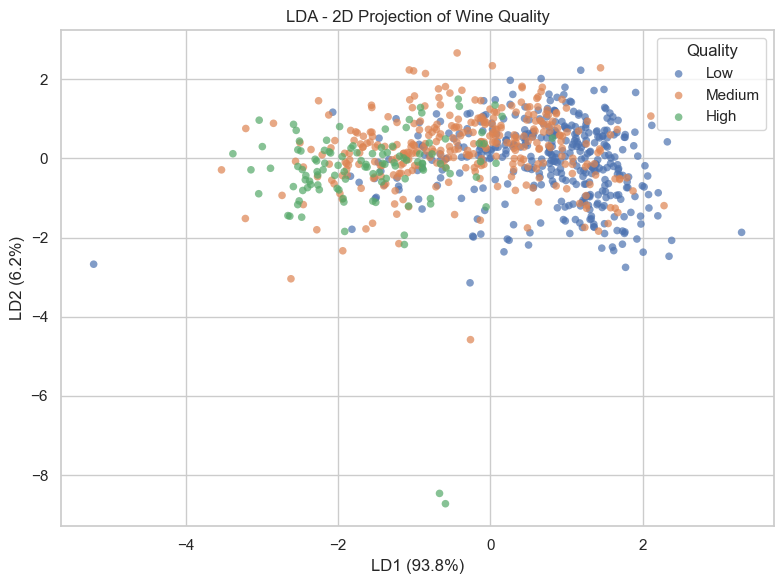

In [23]:
# Visualisasi 2D LDA

fig, ax = plt.subplots(figsize=(8, 6))

for cls in label_order:
    idx = y_train == cls
    ax.scatter(
        X_train_lda[idx, 0],
        X_train_lda[idx, 1],
        label=cls,
        alpha=0.7,
        edgecolor='none',
        s=30
    )

ax.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('LDA - 2D Projection of Wine Quality')
ax.legend(title='Quality')
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

proyeksi 2D LDA menunjukkan pemisahan kelas yang jauh lebih baik dibanding PCA. kelas High, Medium, dan Low terlihat lebih terpisah karena LDA dirancang khusus memaksimalkan jarak antar kelas saat melakukan reduksi dimensi, bukan hanya mencari arah variansi terbesar

In [24]:
# Train Random Forest dengan LDA Data

rf_lda = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_lda.fit(X_train_lda, y_train)
y_pred_lda = rf_lda.predict(X_test_lda)

**Interpretasi cell diatas**:

Random Forest dilatih menggunakan 2 komponen LDA sebagai fitur. meskipun dimensinya sangat kecil hanya 2, LDA sudah mengoptimalkan kedua komponen ini untuk memisahkan kelas sehingga informasi yang paling berguna untuk klasifikasi tetap terjaga

In [25]:
# Evaluasi LDA

print(f"Accuracy with LDA: {accuracy_score(y_test, y_pred_lda)*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_lda, labels=label_order, zero_division=0))

Accuracy with LDA: 55.88%

Classification Report:
              precision    recall  f1-score   support

         Low       0.66      0.72      0.69        95
      Medium       0.47      0.46      0.47        82
        High       0.38      0.30      0.33        27

    accuracy                           0.56       204
   macro avg       0.51      0.49      0.50       204
weighted avg       0.55      0.56      0.55       204



**Interpretasi cell diatas**:

classification report LDA menampilkan performa model per kelas dengan urutan Low, Medium, High. LDA hanya menghasilkan 2 dimensi (n_kelas - 1 = 2) sehingga lebih terbatas dibanding PCA yang menggunakan 7 komponen. untuk dataset ini PCA bisa menghasilkan accuracy lebih tinggi karena lebih banyak informasi yang dipertahankan

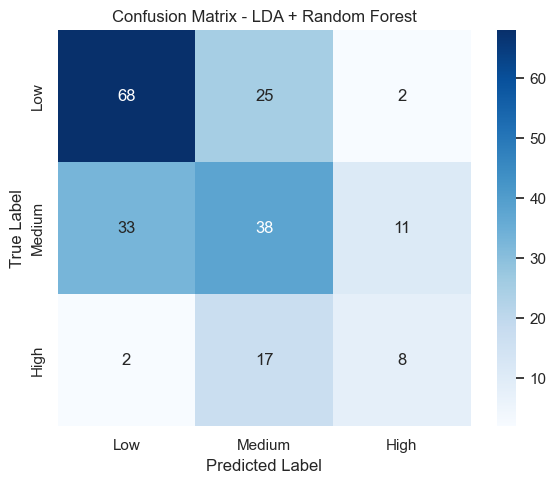

In [26]:
cm_lda = confusion_matrix(y_test, y_pred_lda, labels=label_order)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_lda,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_order,
    yticklabels=label_order,
    ax=ax
)
ax.set_title('Confusion Matrix - LDA + Random Forest')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

confusion matrix LDA memperlihatkan detail prediksi benar dan salah per kelas dan diagonal kiri atas ke kanan bawah adalah prediksi yang benar. dibanding PCA, LDA biasanya menghasilkan pemisahan kelas yang lebih baik karena dirancang khusus untuk memaksimalkan jarak antar kelas saat reduksi dimensi

# t-SNE (t-Distributed Stochastic Neighbor Embedding )

In [27]:
# Gabung Train + Test lalu Fit t-SNE

from sklearn.manifold import TSNE
import numpy as np

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
y_all = pd.concat([y_train, y_test]).reset_index(drop=True)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_all_tsne = tsne.fit_transform(X_all_scaled)

# Pisah kembali sesuai ukuran train
X_train_tsne = X_all_tsne[:len(X_train_scaled)]
X_test_tsne = X_all_tsne[len(X_train_scaled):]

print(f"Shape sebelum t-SNE: {X_all_scaled.shape}")
print(f"Shape setelah t-SNE: {X_all_tsne.shape}")

Shape sebelum t-SNE: (1018, 11)
Shape setelah t-SNE: (1018, 2)


**Interpretasi cell diatas**:

t-SNE tidak memiliki fungsi transform() seperti PCA dan LDA, sehingga data train dan test digabung dulu sebelum di-fit agar koordinat 2D-nya konsisten satu sama lain. setelah selesai, hasilnya dipisah kembali menjadi train dan test sesuai ukuran awal menggunakan index. perplexity=30 adalah nilai default yang cocok untuk dataset berukuran menengah seperti ini

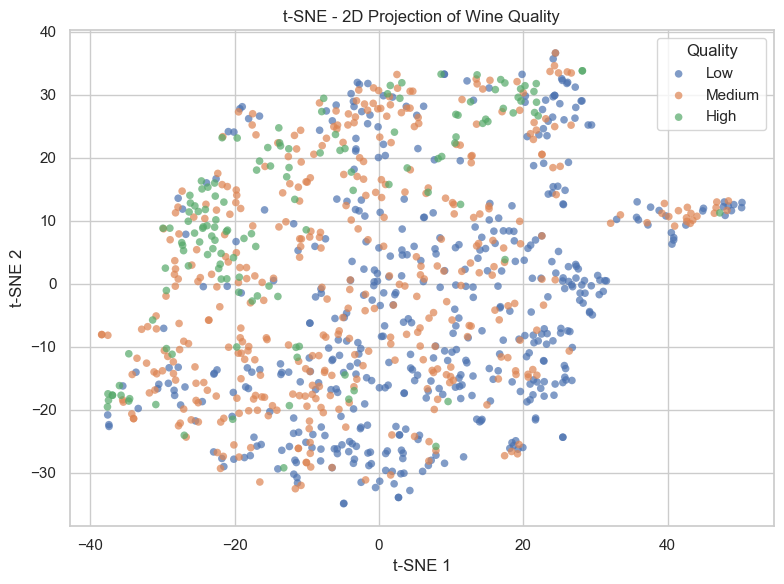

In [28]:
# Visualisasi 2D t-SNE

fig, ax = plt.subplots(figsize=(8, 6))

for cls in label_order:
    idx = (y_all == cls).values
    ax.scatter(
        X_all_tsne[idx, 0],
        X_all_tsne[idx, 1],
        label=cls,
        alpha=0.7,
        edgecolor='none',
        s=30
    )

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE - 2D Projection of Wine Quality')
ax.legend(title='Quality')
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

visualisasi t-SNE menampilkan struktur lokal data yang lebih jelas dibanding PCA. data yang mirip cenderung mengelompok berdekatan. namun perlu diingat bahwa jarak antar kelompok dalam t-SNE tidak selalu mencerminkan jarak sebenarnya dalam ruang dimensi tinggi, sehingga t-SNE lebih cocok untuk visualisasi daripada analisis kuantitatif

In [29]:
# Train Random Forest dengan t-SNE Data

rf_tsne = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_tsne.fit(X_train_tsne, y_train)
y_pred_tsne = rf_tsne.predict(X_test_tsne)

**Interpretasi cell diatas**:

Random Forest dilatih menggunakan koordinat 2D hasil t-SNE sebagai fitur. meskipun hanya 2 dimensi, t-SNE sudah merangkum pola lokal yang penting dari data asli. class_weight parameter tetap digunakan untuk menangani ketidakseimbangan antar kelas

In [30]:
# Evaluasi t-SNE

print(f"Accuracy with t-SNE: {accuracy_score(y_test, y_pred_tsne)*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_tsne, labels=label_order, zero_division=0))

Accuracy with t-SNE: 53.43%

Classification Report:
              precision    recall  f1-score   support

         Low       0.62      0.73      0.67        95
      Medium       0.46      0.39      0.42        82
        High       0.35      0.30      0.32        27

    accuracy                           0.53       204
   macro avg       0.48      0.47      0.47       204
weighted avg       0.52      0.53      0.52       204



**Interpretasi cell diatas**:

classification report t-SNE menampilkan performa model per kelas. t-SNE memang bagus untuk visualisasi dan menangkap kluster lokal, namun hasilnya untuk klasifikasi bisa lebih rendah dari LDA karena t-SNE tidak dirancang khusus untuk memaksimalkan pemisahan antar kelas

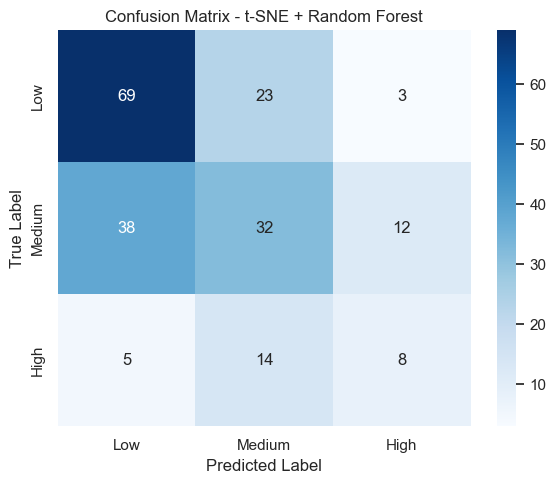

In [31]:
cm_tsne = confusion_matrix(y_test, y_pred_tsne, labels=label_order)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_tsne,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_order,
    yticklabels=label_order,
    ax=ax
)
ax.set_title('Confusion Matrix - t-SNE + Random Forest')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

confusion matrix t-SNE memperlihatkan pola kesalahan klasifikasi. karena t-SNE hanya menggunakan 2 dimensi, informasi yang tersedia untuk classifier lebih terbatas dibanding LDA yang juga 2 dimensi tetapi dioptimalkan untuk pemisahan kelas secara eksplisit

# Comparative Analysis

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {}
for name, y_pred in [('PCA', y_pred_pca), ('LDA', y_pred_lda), ('t-SNE', y_pred_tsne)]:
    results[name] = {
        'Accuracy'        : accuracy_score(y_test, y_pred),
        'Macro Precision' : precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Macro Recall'    : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'Macro F1-Score'  : f1_score(y_test, y_pred, average='macro', zero_division=0),
    }

df_results = pd.DataFrame(results).T
print(df_results.round(4))

       Accuracy  Macro Precision  Macro Recall  Macro F1-Score
PCA      0.6520           0.6387        0.5806          0.5971
LDA      0.5588           0.5054        0.4918          0.4964
t-SNE    0.5343           0.4759        0.4710          0.4702


**Interpretasi cell diatas**:

tabel perbandingan macro metrics ketiga metode reduksi dimensi. macro precision, recall, dan F1-Score dihitung rata-rata tanpa mempertimbangkan jumlah data per kelas sehingga semua kelas diperlakukan setara. ini lebih adil untuk dataset yang masih agak tidak seimbang seperti data wine ini

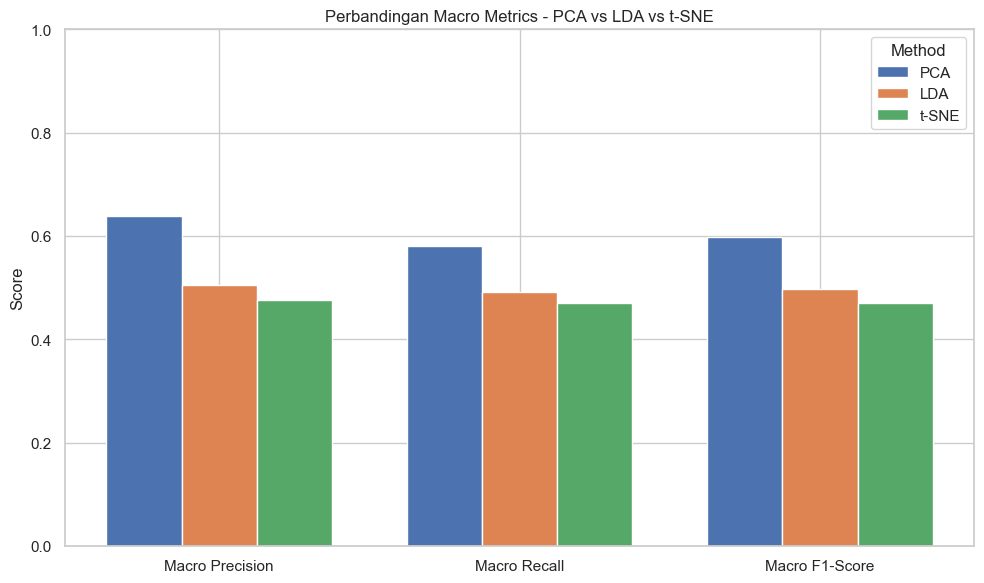

In [33]:
import numpy as np

metrics = ['Macro Precision', 'Macro Recall', 'Macro F1-Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, (model, row) in enumerate(df_results.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=model)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Macro Metrics - PCA vs LDA vs t-SNE')
ax.legend(title='Method')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Interpretasi cell diatas**:

menampilkan bar chart yang memudahkan perbandingan visual ketiga metode sekaligus. metode dengan bar tertinggi pada macro F1-Score adalah yang paling seimbang dalam mengklasifikasi semua kelas wine. perbedaan antar metode paling terlihat di macro recall karena masing-masing kelas punya jumlah data yang berbeda

## Ringkasan Comparative Analysis

dari pipeline, tabel dan grafik di atas terdapat beberapa kesimpulan yang bisa ditarik yaiut,

- **PCA** tidak mempertimbangkan label kelas saat reduksi, hanya mencari arah dengan variansi terbesar. karena itu PCA kurang optimal untuk klasifikasi meskipun tetap berguna untuk preprocessing umum
- **LDA** bersifat supervised, artinya proses reduksi dimensi memanfaatkan informasi label kelas untuk memaksimalkan pemisahan antar kelas Low, Medium, dan High
- **t-SNE** unggul dalam menangkap struktur lokal data dan menghasilkan visualisasi yang jelas, namun hanya menghasilkan 2 dimensi sehingga informasi yang tersedia untuk classifier lebih terbatas